# Review: Why Did Claude Pick Those Tickers?

In the [Session 1 interview](../session-1/interview.md), each archetype maps to a curated list of 20 to 24 tickers. The lists encode two priors at once: the investor's stated objective (income, balanced, growth) and a sector-balance constraint that no archetype puts all its weight on a single industry. The lists were not learned from data; _Claude wrote them_.

In this example, we ask the question: __could a learning-based ticker picker have done better?__ We benchmark the curated archetype baskets against a per-sector sparse bandit on the real 2025-2026 hold-out window, with the bandit trained on 2014-2024 history. The bandit gets the same sector-balance constraint the archetypes do; the only thing it adds is data.

The learning objectives below frame the theory recap and the two results tables that follow.

> __Learning Objectives:__
>
> By the end of this example, we will be able to:
> * __Reformulate basket selection as 11 small per-sector bandits:__ State the action, the arm, and the reward for a single sector and explain why the per-sector decomposition collapses the action space. Recognize that the cross-sectional reward strips away the market-beta variance that dominates raw forward returns.
> * __Read a Monte Carlo distribution against a deterministic baseline:__ Compare the trained bandit's median-seed outcome to the deterministic Claude-curated archetype baskets and the Full-Universe baseline. Distinguish a single-trial number from the distribution it was drawn from.
> * __Diagnose when picking adds value vs when diversification does:__ Identify the basket size at which per-sector picking becomes a real edge over the curated lists. Recognize why a curated archetype that aligns with the realized regime is the hardest baseline to beat.

Let's walk through the theory and read the bake-off.

___

## Section 1: Theory Recap
The picker we benchmark in this notebook reuses the [combinatorial epsilon-greedy bandit from Session 3](../session-3/eCornell-AI-Finance-S3-Example-Core-TickerPickerBandit-May-2026.ipynb) but reorganizes it. The Session 3 setup picked a basket from one (giant) universe; here we pick tickers for 11 baskets, one per GICS sector, each with its own arms and reward.

> __Why the per-sector reformulation:__
>
> The Session 3 bandit enumerated $2^{22} - 1 \approx 4.2$ million arms by storing one arm-mean per subset. At production scale ($K = 413$, $K_{\text{basket}} = 22$) every naive lift is dead on arrival: the all-subsets count is $2^{K} - 1 \approx 10^{124}$, and even the fixed-basket table $\binom{K}{K_{\text{basket}}} \approx 1.8 \times 10^{36}$ cannot be visited or stored. 
> 
> The per-sector decomposition sidesteps the cross-product with three design choices:
>
> * __Per-sector partition:__ The 413-ticker universe splits along its $S = 11$ GICS sectors, and we run eleven parallel epsilon-greedy bandits, one per sector, each picking a $q_s$-ticker sub-basket from its sector's $N_s$ candidates with $\sum_s q_s = K_{\text{basket}} = 22$.
> * __No cross-sector coordination:__ Each bandit sees only its within-sector arms $\binom{N_s}{q_s}$ and its own sector-relative 21-day realized log return of the Cobb-Douglas-allocated sub-basket; sectors do not exchange information or share an arm table.
> * __Sum, not product:__ Because the bandits run in parallel rather than nested, the total arm count is $\sum_{s=1}^{S} \binom{N_s}{q_s} \approx 7{,}700$, not the product of per-sector counts, and that is the entire point of the decomposition.
>
> That replaces the one-giant-bandit table of $\sim 10^{36}$ with $\sim 10^{4}$, a collapse of roughly thirty-two orders of magnitude.

The setup formalizes one bandit per sector with a quota that fixes how many slots that sector contributes to the assembled basket.

> __Per-sector setup:__
>
> * Universe: $K = 413$ S&P 500 tickers, partitioned into $S = 11$ GICS sectors with sector-$s$ size $N_s$.
> * Quota vector: $\mathbf{q} = (q_1, \ldots, q_S)$ with $\sum_s q_s = K_{\text{basket}}$. The bandit picks exactly $q_s$ tickers from sector $s$.
> * Arms: writing $\mathcal{N}_s = \{1, \ldots, N_s\}$ for the within-sector ticker indices, a sector-$s$ arm $\mathcal{B} \subseteq \mathcal{N}_s$ is a sorted $q_s$-tuple. Sector $s$ has $\binom{N_s}{q_s}$ arms.
> * Reward (sector-relative): for arm $\mathcal{B}$ on training day $t$ over horizon $h = 21$ trading days, the reward is given by:
> $$
R_s(\mathcal{B}, t) \;=\; r_{\mathcal{B}}(t, t+h) \;-\; r_{\text{EW}, s}(t, t+h)
$$
> where $r_{\mathcal{B}}$ is the basket's Cobb-Douglas-allocated buy-and-hold log return and $r_{\text{EW}, s}$ is the equal-dollar-weighted log return of all tickers in sector $s$ over the same window.

The pseudocode below specifies one sector's bandit. We run $S = 11$ such bandits in parallel, one per GICS sector, and concatenate the winning sub-baskets into a single deployable basket of size $K_{\text{basket}} = \sum_s q_s$.

### Algorithm: Per-Sector Sparse Bandit (Offline Training)

__Initialize__: Given a sector $s$ with within-sector ticker indices $\mathcal{N}_s = \{1, \ldots, N_s\}$, a quota $q_s \in \mathbb{Z}_{>0}$, the action set $\mathcal{A}_s = \{\mathcal{B} \subseteq \mathcal{N}_s : |\mathcal{B}| = q_s\}$ of cardinality $|\mathcal{A}_s| = \binom{N_s}{q_s}$, a training-day set $\mathcal{D}_{\text{train}} \subset \mathbb{Z}$, a forward horizon $h$ (trading days), an iteration budget $T$, and an exploration floor $\varepsilon_{\min} \in (0, 1)$, set the running sample-mean estimate $\hat{\mu}_{\mathcal{B}} \gets 0$ and the pull count $n_{\mathcal{B}} \gets 0$ for each visited arm $\mathcal{B} \in \mathcal{A}_s$.

For $t = 1, \ldots, T$ __do__:

1. Compute the exploration rate: $\varepsilon_t \gets \max(\varepsilon_{\min},\; t^{-1/3} \cdot (|\mathcal{A}_s| \ln t)^{1/3})$.
2. Draw $p \sim \mathrm{Uniform}[0, 1]$ and select an arm:
    - If $p \leq \varepsilon_t$ or no arm has been visited yet, *explore*: sample $\mathcal{B}_t$ uniformly from $\mathcal{A}_s$.
    - Otherwise, *exploit*: set $\mathcal{B}_t \gets \arg\max_{\mathcal{B} \,\text{visited}} \hat{\mu}_{\mathcal{B}}$.
3. Sample a training day $d_t \sim \mathrm{Uniform}(\mathcal{D}_{\text{train}})$ and observe the sector-relative reward $r_t \gets R_s(\mathcal{B}_t, d_t) = r_{\mathcal{B}_t}(d_t, d_t + h) - r_{\text{EW}, s}(d_t, d_t + h)$.
4. Update the pulled arm:
    $$n_{\mathcal{B}_t} \gets n_{\mathcal{B}_t} + 1, \qquad \hat{\mu}_{\mathcal{B}_t} \gets \hat{\mu}_{\mathcal{B}_t} + \frac{1}{n_{\mathcal{B}_t}}\left(r_t - \hat{\mu}_{\mathcal{B}_t}\right)$$

__Output__: Return the learned sub-basket $\mathcal{B}_s^{\star} = \arg\max_{\mathcal{B} \,\text{visited}} \hat{\mu}_{\mathcal{B}}$, the visited-arm means $\{\hat{\mu}_{\mathcal{B}}\}$, pull counts $\{n_{\mathcal{B}}\}$, and the chosen-arm history $\{(\mathcal{B}_t, r_t)\}_{t=1}^{T}$.

The 11 sector winners assemble into the full deployable basket $\mathcal{B}^{\star} = \bigcup_{s=1}^{S} \mathcal{B}_s^{\star}$, which the daily Cobb-Douglas rebalancing engine walks through the 2025-2026 hold-out window.

The implementation lives in three scripts (linked here for reference; the notebook only loads their saved results below):

* [`scripts/bandit/per_sector_bandit.jl`](scripts/bandit/per_sector_bandit.jl) trains one bandit per sector, assembles the basket, deploys on the hold-out window, and saves a single-seed scorecard.
* [`scripts/bandit/monte_carlo_per_sector_bandit.jl`](scripts/bandit/monte_carlo_per_sector_bandit.jl) repeats the same training and deployment with 30 different seeds and saves the distribution of hold-out metrics.
* [`scripts/bandit/compare_archetypes.jl`](scripts/bandit/compare_archetypes.jl) deploys each Session 1 archetype basket on the same hold-out window and joins the result with the bandit's MC distribution and the Full-Universe baseline.

___

## Section 2: Results
We split the timeline into a training window and a hold-out window. The bandit sees only training-window data when it learns; every metric we report below is computed on the hold-out window.

> __Data windows:__
>
> * __Training:__ 2014-01-03 to 2024-12-31, ~10 years of daily closes for the 413-ticker universe. The bandit samples training days from this window and computes a 21-day forward sector-relative reward for each candidate arm.
> * __Hold-out:__ 2025-01-02 to 2026-04-22, 326 trading days of daily closes. Every assembled basket (bandit, archetype, or Full-Universe) is forward-walked through the daily Cobb-Douglas rebalancing engine on this window with the same drawdown and turnover rules.
> * __Universe filter:__ S&P 500 tickers with full OHLC coverage on every training day and every hold-out day. The filter drops delisted names and ETFs; what remains is the 413-ticker production universe.

The bandit's exploration order depends on its random seed, so a single training run produces a noisy point estimate. We therefore train the picker 30 times with seeds $1001, \ldots, 1030$, deploy each resulting basket on the same hold-out window, and report the distribution of outcomes alongside the deterministic archetype and Full-Universe baselines.

The code block below loads the saved bake-off results into `results::Dict{String,Any}` for use in subsequent cells. No training happens in this notebook.

In [1]:
# --- Step 1: Pull in shared types, JLD2/CSV helpers, plotting, and the project root path ---
include("Include.jl")

# --- Step 2: Load the bake-off results written by scripts/bandit/compare_archetypes.jl ---
# `results::Dict{String,Any}` carries every output we render below: per-archetype
# scorecards, the 30-seed Sector-Bandit Monte Carlo distribution, the random-per-sector
# baseline distribution, the Full-Universe scorecard, and the forward-window metadata.
# No training happens in this notebook; all numbers come from this on-disk artifact.
results = load(joinpath(_ROOT, "scripts", "bandit", "compare_archetypes_results.jld2"))

# --- Step 3: Guard against a stale results file ---
# K_COMPARE is the basket size used in the bake-off (= 22, matching the archetype range).
# MC_N_SEEDS is the number of independent bandit training runs (= 30). These two values
# are the only hyperparameters every downstream comparison assumes, so we assert them.
@assert results["K_COMPARE"] == 22  "expected K_COMPARE = 22 (uniform q_s = 2 across 11 sectors)"
@assert results["MC_N_SEEDS"] == 30 "expected 30 Monte Carlo seeds"

# --- Step 4: Echo the bake-off setup so the reader knows what window we are on ---
println("Bake-off K_COMPARE  : ", results["K_COMPARE"], " (uniform q_s = 2 across all 11 sectors)")
println("Monte Carlo seeds   : ", results["MC_N_SEEDS"], " (seeds ", results["MC_SEED_BASE"]+1, ":", results["MC_SEED_BASE"]+results["MC_N_SEEDS"], ")")
println("Forward window      : ", results["forward_first_date"], " to ", results["forward_last_date"], " (", results["n_fwd"], " trading days)")

Bake-off K_COMPARE  : 22 (uniform q_s = 2 across all 11 sectors)
Monte Carlo seeds   : 30 (seeds 1001:1030)
Forward window      : 2025-01-02 to 2026-04-22 (326 trading days)


__Monte Carlo distribution at $K_{\text{basket}} = 22$:__ Each row below summarizes the 30-seed distribution of one strategy's hold-out metrics. The Sector-Bandit rows are the per-sector bandit trained on 2014-2024 with sector-relative reward; the Random-per-sector rows pick $q_s$ tickers uniformly at random within each sector (same sector quotas, no learning). Compare medians across rows, not single values within a row.

In [8]:
let
    # --- Step 1: Pull the 30-seed Monte Carlo distributions for each strategy ---
    # sb_* are the Sector-Bandit (trained per-sector with epsilon-greedy on the
    # sector-relative reward); rs_* are the Random-per-sector baseline (same
    # sector quotas, but each sector's slots are filled by uniform random draw,
    # no learning). Each of these is a length-30 vector indexed by MC seed.
    sb_W = results["sb_W_T_mc"];   rs_W = results["rs_W_T_mc"]    # terminal wealth multiple W_T / W_0
    sb_S = results["sb_sharpe_mc"]; rs_S = results["rs_sharpe_mc"] # annualized hold-out Sharpe
    sb_D = results["sb_dd_mc"];    rs_D = results["rs_dd_mc"]     # maximum drawdown over the hold-out window (%)

    # --- Step 2: Five-number summary helper for one metric vector ---
    # Returns (min, 25th percentile, median, 75th percentile, max), each rounded
    # to 3 digits. We call this once per (strategy, metric) cell of the table.
    qstats(x) = (round(minimum(x); digits=3), round(quantile(x, 0.25); digits=3),
                 round(median(x);   digits=3), round(quantile(x, 0.75); digits=3),
                 round(maximum(x); digits=3))

    # --- Step 3: Build one summary row per (strategy, metric) pair ---
    # Two strategies (Sector-Bandit, Random-per-sector) times three metrics
    # (W_T / W_0, Sharpe, Max DD %) = 6 rows. The grouping puts both strategies'
    # values for the same metric next to each other, so the reader compares
    # medians ACROSS rows of the same Metric, not WITHIN a single row.
    rows = NamedTuple[]
    for (label, w, s, d) in [
            ("Sector-Bandit",     sb_W, sb_S, sb_D),
            ("Random-per-sector", rs_W, rs_S, rs_D)]
        wmin, w25, wmed, w75, wmax = qstats(w)
        smin, s25, smed, s75, smax = qstats(s)
        dmin, d25, dmed, d75, dmax = qstats(d)
        push!(rows, (Strategy = label, Metric = "W_T / W_0",
            Min = wmin, Q25 = w25, Median = wmed, Q75 = w75, Max = wmax))
        push!(rows, (Strategy = label, Metric = "Sharpe",
            Min = smin, Q25 = s25, Median = smed, Q75 = s75, Max = smax))
        push!(rows, (Strategy = label, Metric = "Max DD %",
            Min = dmin, Q25 = d25, Median = dmed, Q75 = d75, Max = dmax))
    end

    # --- Step 4: Render the distribution table ---
    pretty_table(DataFrame(rows); backend = :text,
        fit_table_in_display_horizontally = false, 
        fit_table_in_display_vertically = false, 
        table_format = TextTableFormat(borders = text_table_borders__compact)
    );
end

 ------------------- ----------- --------- --------- --------- --------- ---------
           Strategy      Metric       Min       Q25    Median       Q75       Max 
             String      String   Float64   Float64   Float64   Float64   Float64 
 ------------------- ----------- --------- --------- --------- --------- ---------
      Sector-Bandit   W_T / W_0     0.865     1.075     1.147     1.197     1.369
      Sector-Bandit      Sharpe    -2.507     0.101     0.502     0.883     1.886
      Sector-Bandit    Max DD %     5.405     7.944     9.079    11.471    15.444
  Random-per-sector   W_T / W_0     0.988     1.063     1.107     1.182      1.35
  Random-per-sector      Sharpe    -0.501     0.015     0.354     0.826     1.723
  Random-per-sector    Max DD %     4.429     6.453     7.514     9.097    13.359
 ------------------- ----------- --------- --------- --------- --------- ---------


The MC distribution above is one half of the comparison. The other half is the deterministic baselines: the 5 Claude-curated archetype baskets from the Session 1 interview, plus the Full-Universe basket of all 413 tickers. Each of those is a fixed list, so it produces a single number per metric.

__Hold-out bake-off (single point per strategy):__ The 5 archetypes and the Full-Universe baseline contribute one row each (no randomness). The Sector-Bandit and Random-per-sector rows report the median across the 30 Monte Carlo seeds. Sorted by hold-out Sharpe, descending.

In [3]:
let
    # --- Step 1: Pull the deterministic baselines from the results dict ---
    # `arch::Dict{String,<:NamedTuple}` maps each archetype name (e.g. "AggressiveGrowth")
    # to its hold-out scorecard with fields .W_T_over_W0, .ann_ret, .max_dd, .sharpe.
    # `kept::Dict{String,Vector{String}}` maps each archetype name to the tickers that
    # survived the universe filter; we use it only for length (the basket size K).
    # `fu::NamedTuple` is the Full-Universe scorecard (all 413 tickers, equal-weight).
    # `n_fwd::Int` is the number of trading days in the hold-out window; we use it
    # below to annualize the bandit's log return.
    arch  = results["archetype_metrics"]
    kept  = results["archetype_kept"]
    fu    = results["full_universe_metrics"]
    n_fwd = results["n_fwd"]

    # --- Step 2: Collapse the 30-seed distributions to single numbers via median ---
    # Each strategy contributes exactly one row to the bake-off, so we take the
    # MC median per metric. sb_* = Sector-Bandit; rs_* = Random-per-sector baseline.
    sb_W_med = median(results["sb_W_T_mc"])    # terminal wealth multiple, median across 30 seeds
    sb_S_med = median(results["sb_sharpe_mc"]) # hold-out Sharpe, median across 30 seeds
    sb_D_med = median(results["sb_dd_mc"])     # max drawdown %, median across 30 seeds
    rs_W_med = median(results["rs_W_T_mc"])
    rs_S_med = median(results["rs_sharpe_mc"])
    rs_D_med = median(results["rs_dd_mc"])

    # --- Step 3: Row constructor for the bake-off table ---
    # Columns: Strategy, K (basket size), W_T_over_W0, Ann_ret_pct, Max_DD_pct, Sharpe.
    # Display values rounded to a few digits so the table reads cleanly.
    row(strategy::String, K::Int, w::Real, ann::Real, dd::Real, sh::Real) = (
        Strategy = strategy, K = K,
        W_T_over_W0 = round(w; digits = 3),
        Ann_ret_pct = round(ann; digits = 2),
        Max_DD_pct  = round(dd; digits = 1),
        Sharpe      = round(sh; digits = 3))

    # --- Step 4: Assemble rows for all 8 strategies ---
    # First the 5 archetype baselines (one row each). Then the Sector-Bandit and
    # Random-per-sector MC medians. Finally the Full-Universe (K = 413). Archetype
    # metrics carry ann_ret and max_dd as fractions, so we multiply by 100 for
    # display. The bandit row's annualized return is recovered from the wealth
    # multiple as log(W_T / W_0) * (252 / n_fwd) * 100 to put it on the same scale.
    rows = NamedTuple[]
    for (name, m) in arch
        push!(rows, row(name, length(kept[name]),
            m.W_T_over_W0, m.ann_ret * 100, m.max_dd * 100, m.sharpe))
    end
    push!(rows, row("Sector-Bandit (MC median)", results["K_COMPARE"],
        sb_W_med, log(sb_W_med) * (252.0 / n_fwd) * 100, sb_D_med, sb_S_med))
    push!(rows, row("Random-per-sector (MC median)", results["K_COMPARE"],
        rs_W_med, log(rs_W_med) * (252.0 / n_fwd) * 100, rs_D_med, rs_S_med))
    push!(rows, row("Full-Universe", 413,
        fu.W_T_over_W0, fu.ann_ret * 100, fu.max_dd * 100, fu.sharpe))

    # --- Step 5: Sort by Sharpe descending and render ---
    # Sharpe is the ranking metric for the bake-off question; the highest-Sharpe
    # strategy appears at the top of the table.
    sort!(rows; by = r -> -r.Sharpe)
    pretty_table(DataFrame(rows); backend = :text,
        fit_table_in_display_horizontally = false, 
        table_format = TextTableFormat(borders = text_table_borders__compact)
    );
end

 ------------------------------- ------- ------------- ------------- ------------ ---------
                       Strategy       K   W_T_over_W0   Ann_ret_pct   Max_DD_pct    Sharpe 
                         String   Int64       Float64       Float64      Float64   Float64 
 ------------------------------- ------- ------------- ------------- ------------ ---------
               AggressiveGrowth      20         1.157         11.34         11.6     0.552
      Sector-Bandit (MC median)      22         1.147         10.63          9.1     0.502
                  Full-Universe     413         1.166         11.88         13.1      0.49
  Random-per-sector (MC median)      22         1.107          7.88          7.5     0.354
                 GrowthOriented      22         1.104          7.69         11.1     0.313
             ConservativeIncome      20         1.097          7.21          5.8     0.298
                       Balanced      22         1.092          6.84          7.6     0

The bake-off table compares median performance across the 30 bandit seeds to the deterministic baselines. The median Sector-Bandit beats four of the five Claude-curated archetypes and ties the one it cannot reliably beat. The Random-per-sector baseline, which has the same sector quotas but no learning, beats only two archetypes and ties one.

* __Wait, hold up. The random ticker beat Claude's curated list?__ Yes, the Random-per-sector baseline beats two of the five archetypes and ties one. The Claude curated list is not magical; it is a single point in the space of possible baskets. It is not a surprise that a random basket with the same sector quotas can beat it sometimes; the surprise would be if it never did (meaning Claude has some magical powers).
* __Where does each archetype sit in the bandit's Sharpe distribution?__ How many times does the bandit beat each archetype? The _Bandit beats it %_ is the percentage of the 30 bandit seeds whose hold-out Sharpe exceeds the archetype's Sharpe. A value above 50% means a typical bandit run beats that archetype; a value near 50% is a coin flip.

The _sector bandit_ lost to the __Aggressive Growth__ archetype, but how bad did it loose to this archetype? 

In [ ]:
let
    # --- Step 1: Pull the archetype scorecards and the bandit's 30-seed Sharpe vector ---
    arch = results["archetype_metrics"]   # archetype name -> NamedTuple of hold-out metrics
    sb_S = results["sb_sharpe_mc"]        # length-30 vector of hold-out Sharpe, one per bandit seed

    # --- Step 2: For each archetype, count how many bandit seeds beat its Sharpe ---
    # `wins` is the number of seeds (out of 30) whose hold-out Sharpe exceeds the
    # archetype's deterministic Sharpe. Converting to a percentage gives the
    # head-to-head win rate. Archetypes are sorted by descending Sharpe so the
    # strongest baseline appears at the top of the table.
    rows = NamedTuple[]
    for (name, m) in sort(collect(arch); by = p -> -p[2].sharpe)
        wins = sum(>(m.sharpe), sb_S)
        push!(rows, (
            Archetype           = name,
            Archetype_Sharpe    = round(m.sharpe; digits = 3),
            Bandit_beats_it_pct = round(100 * wins / length(sb_S); digits = 0),
            Archetype_beats_pct = round(100 * (length(sb_S) - wins) / length(sb_S); digits = 0)))
    end

    # --- Step 3: Render the head-to-head win-rate table ---
    pretty_table(DataFrame(rows); backend = :text,
        fit_table_in_display_horizontally = false, 
        table_format = TextTableFormat(borders = text_table_borders__compact)
    );
end

 -------------------- ------------------ --------------------- ---------------------
           Archetype   Archetype_Sharpe   Bandit_beats_it_pct   Archetype_beats_pct 
              String            Float64               Float64               Float64 
 -------------------- ------------------ --------------------- ---------------------
    AggressiveGrowth              0.552                  47.0                  53.0
      GrowthOriented              0.313                  67.0                  33.0
  ConservativeIncome              0.298                  67.0                  33.0
            Balanced              0.247                  67.0                  33.0
  ConservativeGrowth             -0.102                  80.0                  20.0
 -------------------- ------------------ --------------------- ---------------------


The histogram below renders the same comparison visually: the 30-seed bandit Sharpe distribution at $K_{\text{basket}} = 22$, with vertical lines marking each archetype's deterministic Sharpe and the Full-Universe Sharpe. Archetypes to the left of the bandit median lose to a typical bandit run; archetypes to the right beat it.

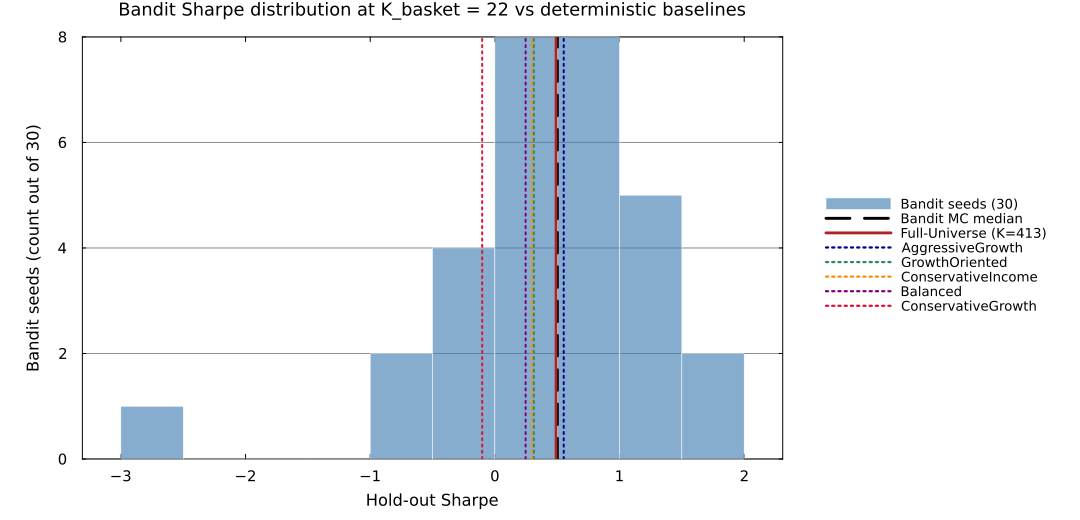

In [5]:
let
    # --- Step 1: Pull the bandit Sharpe distribution and the deterministic baselines ---
    sb_S = results["sb_sharpe_mc"]            # 30-seed hold-out Sharpe vector
    arch = results["archetype_metrics"]       # archetype name -> hold-out scorecard
    fu   = results["full_universe_metrics"]   # Full-Universe scorecard

    # --- Step 2: Histogram the bandit's 30-seed Sharpe distribution ---
    # Each bin counts how many trained bandits produced a hold-out Sharpe in that
    # range. White background, subtle horizontal grid, and the legend pushed outside
    # the panel so the 7 baselines do not crowd the bars near zero.
    p = histogram(sb_S; bins = 10,
        framestyle = :box,
        background_color = :white, background_color_inside = :white,
        grid = :y, gridalpha = 0.25, gridlinewidth = 1,
        xlabel = "Hold-out Sharpe",
        ylabel = "Bandit seeds (count out of 30)",
        title  = "Bandit Sharpe distribution at K_basket = 22 vs deterministic baselines",
        titlefontsize = 12, guidefontsize = 11, tickfontsize = 10,
        size = (1080, 520),
        label = "Bandit seeds (30)",
        legend = :outerright, foreground_color_legend = nothing,
        legend_background_color = :white, legendfontsize = 9,
        color = :steelblue, fillalpha = 0.65, linecolor = :white, lw = 0.5,
        left_margin = 10Plots.mm, bottom_margin = 6Plots.mm,
        right_margin = 4Plots.mm, top_margin = 4Plots.mm)

    # --- Step 3: Mark the bandit's MC median and the Full-Universe baseline ---
    # Black dashed vertical: where a typical bandit run lands. Solid firebrick:
    # the Full-Universe (K = 413) baseline; any line right of this is outperforming
    # the broadest possible diversification on hold-out Sharpe. Both drawn at higher
    # weight than the archetype lines so they read as reference markers.
    vline!(p, [median(sb_S)]; lw = 2.6, color = :black, ls = :dash,
        label = "Bandit MC median")
    vline!(p, [fu.sharpe]; lw = 2.6, color = :firebrick, ls = :solid,
        label = "Full-Universe (K=413)")

    # --- Step 4: Overlay each archetype's deterministic Sharpe as a dotted line ---
    # Archetypes left of the bandit median (black dashed) lose to a typical bandit run;
    # archetypes right of it beat one. Dotted style keeps these visually subordinate to
    # the two reference lines. Sorted by descending Sharpe so the strongest archetype
    # draws first and gets the first colour slot.
    arch_colors = [:darkblue, :seagreen, :darkorange, :purple, :crimson]
    for (i, (name, m)) in enumerate(sort(collect(arch); by = p -> -p[2].sharpe))
        vline!(p, [m.sharpe]; lw = 2.0, ls = :dot,
            color = arch_colors[mod(i - 1, length(arch_colors)) + 1],
            label = name)
    end

    # --- Step 5: Return the assembled plot ---
    plot(p)
end

__What does this tells us?__
The one archetype the bandit cannot reliably beat is __Aggressive Growth__. Its Tech and Consumer Discretionary tilt aligned with the realized 2025-2026 hold-out window, which is information the bandit cannot extract from training history alone. It sits near the upper tail of the bandit distribution: roughly half of seeds match it and half do not.

__So what's in the growth archetype versus the Sector-Bandit (MC median)?__ The cell below renders the ticker roster for any portfolio in the bake-off so we can see what each basket actually holds. Set `portfolio_choice::String` to one of the seven options listed in the cell header; the code looks up the basket, joins each ticker to its GICS sector, and prints a sorted (sector, ticker) table.

_Note on the bandit baskets:_ "Sector-Bandit" and "Random-per-sector" both show the single representative seed (COMPARE_SEED) saved by [`scripts/bandit/compare_archetypes.jl`](scripts/bandit/compare_archetypes.jl). Each of the 30 Monte Carlo seeds picks a different basket, so there is no single _MC median_ ticker list to display.

In [7]:
let
    # --- Step 1: Choose the portfolio to inspect ---
    # Valid options for `portfolio_choice`:
    #   "Sector-Bandit"       single-seed sector-bandit basket (representative seed)
    #   "Random-per-sector"   single-seed random-per-sector control basket
    #   "AggressiveGrowth"    Claude-curated archetype baskets (from the Session 1 interview)
    #   "GrowthOriented"
    #   "Balanced"
    #   "ConservativeIncome"
    #   "ConservativeGrowth"
    portfolio_choice = "Sector-Bandit"

    # --- Step 2: Resolve the ticker list for the chosen portfolio ---
    # `archetype_kept` maps each archetype name to its surviving tickers; the
    # bandit and random-per-sector baskets are stored under their single-seed keys.
    # We merge them into one lookup keyed by `portfolio_choice`.
    tickers_by_choice = merge(
        results["archetype_kept"],
        Dict("Sector-Bandit"     => results["sb_seed_tickers"],
             "Random-per-sector" => results["rs_seed_tickers"]))
    haskey(tickers_by_choice, portfolio_choice) ||
        error("Unknown portfolio_choice = $(portfolio_choice). Choose from: " *
              join(sort(collect(keys(tickers_by_choice))), ", "))
    tickers = String.(tickers_by_choice[portfolio_choice])

    # --- Step 3: Load the GICS sector map ---
    # The sector CSV lives alongside the project training data. We read it into
    # a Ticker -> Sector lookup so each row in the table below carries both the
    # symbol and its GICS sector.
    sector_csv = joinpath(_ROOT, "..", "..", "code", "src", "data", "sp500-sectors.csv")
    sec_df = CSV.read(sector_csv, DataFrame)
    sector_of = Dict(row.Symbol => row[Symbol("GICS Sector")] for row in eachrow(sec_df))

    # --- Step 4: Render the (sector, ticker) table ---
    # Sort by sector first, then by ticker, so members of the same sector cluster
    # and the per-sector quotas are easy to read off.
    rows = [(Sector = get(sector_of, t, "(unknown)"), Ticker = t) for t in tickers]
    sort!(rows; by = r -> (r.Sector, r.Ticker))
    println("Portfolio: ", portfolio_choice, "   (K = ", length(rows), " tickers)")
    pretty_table(DataFrame(rows); backend = :text,
        fit_table_in_display_horizontally = false, 
        fit_table_in_display_vertically = false, 
        table_format = TextTableFormat(borders = text_table_borders__compact)
    );
end;

Portfolio: Sector-Bandit   (K = 22 tickers)
 ------------------------ --------
                  Sector   Ticker 
                String31   String 
 ------------------------ --------
  Communication Services     NFLX
  Communication Services     NWSA
  Consumer Discretionary        F
  Consumer Discretionary     TSLA
        Consumer Staples      KMB
        Consumer Staples      STZ
                  Energy      MPC
                  Energy      PSX
              Financials      CME
              Financials      USB
             Health Care     AMGN
             Health Care     IDXX
             Industrials      AME
             Industrials      EFX
  Information Technology      APH
  Information Technology      WDC
               Materials       IP
               Materials      SHW
             Real Estate      DLR
             Real Estate      EQR
               Utilities       FE
               Utilities      NRG
 ------------------------ --------


___

## Summary
The per-sector sparse bandit beats four of five Claude-curated archetype baskets at the median seed when the basket size matches the archetype range ($K_{\text{basket}} = 22$, uniform $q_s = 2$). At smaller basket sizes the bandit loses to the curated lists; at the matching size it ties Full-Universe Sharpe with a 5% basket. The only archetype it cannot reliably beat is the one whose thematic tilt matched the realized regime, which is information the bandit cannot extract from training history alone.

> __Key Takeaways:__
>
> * __Per-sector decomposition makes the action space tractable:__ Splitting one all-subsets bandit into eleven small per-sector bandits collapses the arm table by more than thirty orders of magnitude. The cross-sectional reward strips market-beta variance and leaves the picker a high-signal target.
> * __Read distributions, not single trials:__ A single-seed bandit number is a noisy point estimate. The thirty-seed median is the honest comparison against deterministic baselines, and at the basket size that matches the archetype range it ties the Full-Universe Sharpe and beats four of the five archetypes.
> * __Curated intent is hard to beat when it aligns with the regime:__ The Aggressive Growth archetype's Tech-heavy tilt aligned with the 2025-2026 hold-out window, putting it just above the bandit's MC median. The bandit can match it on roughly half of seeds but not reliably outperform it.

This closes the question that opened the notebook. The Session 1 archetype lists are a strong baseline because they encode investment intent and sector balance; a per-sector bandit can match both at the right basket size, but neither is automatic when the basket is too small or the intent is unknown.

### Disclaimer
This content is for educational purposes only and does not constitute investment advice. The examples use real historical data and a frozen SIM calibration; conclusions about a single forward window do not generalize to other markets or time periods.

___